Project Overview

Historically, educational interventions happen after a student fails an exam. The goal of this project was to shift from a reactive grading system to a proactive predictive engine. By analyzing a complex blend of academic effort, socio-economic background, and behavioral metrics, this project built a machine learning pipeline capable of identifying "At-Risk" students weeks before they sit for their final exams, allowing school counselors to allocate limited resources (like free tutoring) where they are mathematically proven to have the highest impact.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, recall_score, precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier

In [59]:
df = pd.read_csv("/content/drive/MyDrive/python/projects /student exam performance analysis/StudentPerformanceFactors.csv")

# **Data Assessment and Findings **

In [60]:
df.info()

# Confirmed all the columns has correct dtypes.
# missing values observed.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [61]:
missing_values = df.isna().mean()*100
missing_values[missing_values >0]

# Missing values in 3 columns. Less than 5%.
# Missing values - Impute mode.

,0
Teacher_Quality,1.180566
Parental_Education_Level,1.362192
Distance_from_Home,1.014076


In [62]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [63]:
cat_cols = df.select_dtypes(exclude = ["number"]).columns.to_list()

for col in cat_cols:
  print("-"*50)
  print(df[col].value_counts(normalize = True)*100, "\n")


num_cols = df.select_dtypes(include = ["number"]).columns.to_list()


--------------------------------------------------
Parental_Involvement
Medium    50.885425
High      28.878462
Low       20.236113
Name: proportion, dtype: float64 

--------------------------------------------------
Access_to_Resources
Medium    50.234600
High      29.892538
Low       19.872862
Name: proportion, dtype: float64 

--------------------------------------------------
Extracurricular_Activities
Yes    59.603451
No     40.396549
Name: proportion, dtype: float64 

--------------------------------------------------
Motivation_Level
Medium    50.718934
Low       29.317391
High      19.963675
Name: proportion, dtype: float64 

--------------------------------------------------
Internet_Access
Yes    92.447404
No      7.552596
Name: proportion, dtype: float64 

--------------------------------------------------
Family_Income
Low       40.441956
Medium    40.351143
High      19.206902
Name: proportion, dtype: float64 

--------------------------------------------------
Teacher_Qu

Exam score has a standard deviation of 3.9.

50% of the student score between 65 to 69.
This narrow variance will impact the model and metric interpretation.

Mean and median of the exam score both seemed to have been reduced. This indicated a genuine decline in the performance of the students.

The std deviation(spread) - students score are more tighlty cluster around the mean now.

# **Data Cleaning**

In [64]:
# remove impossible score

df = df[ df["Exam_Score"] <= 100 ].copy()

#impute missing values.

missing_cols = list(missing_values[missing_values >0].index)

for col in missing_cols:
  df[col] = df[col].fillna( df[col].mode()[0] )

# **Encoding**

In [65]:
ordinal_orders = {
    "Motivation_Level":        ["Low", "Medium", "High"],
    "Parental_Involvement":    ["Low", "Medium", "High"],
    "Access_to_Resources":     ["Low", "Medium", "High"],
    "Family_Income":           ["Low", "Medium", "High"],
    "Teacher_Quality":         ["Low", "Medium", "High"],
    "Distance_from_Home":      ["Far", "Moderate", "Near"],
    "Parental_Education_Level":["High School", "College", "Postgraduate"],
    "Peer_Influence":          ["Negative", "Neutral", "Positive"]
}

for col,order in ordinal_orders.items():
  df[col] = pd.Categorical(df[col], categories = order, ordered = True)

# **EDA**

In [66]:
df["grades"] = pd.cut(df["Exam_Score"], bins = [0,63,67,71,100], labels = ["At risk", "Average", "Good", "Excellent"])

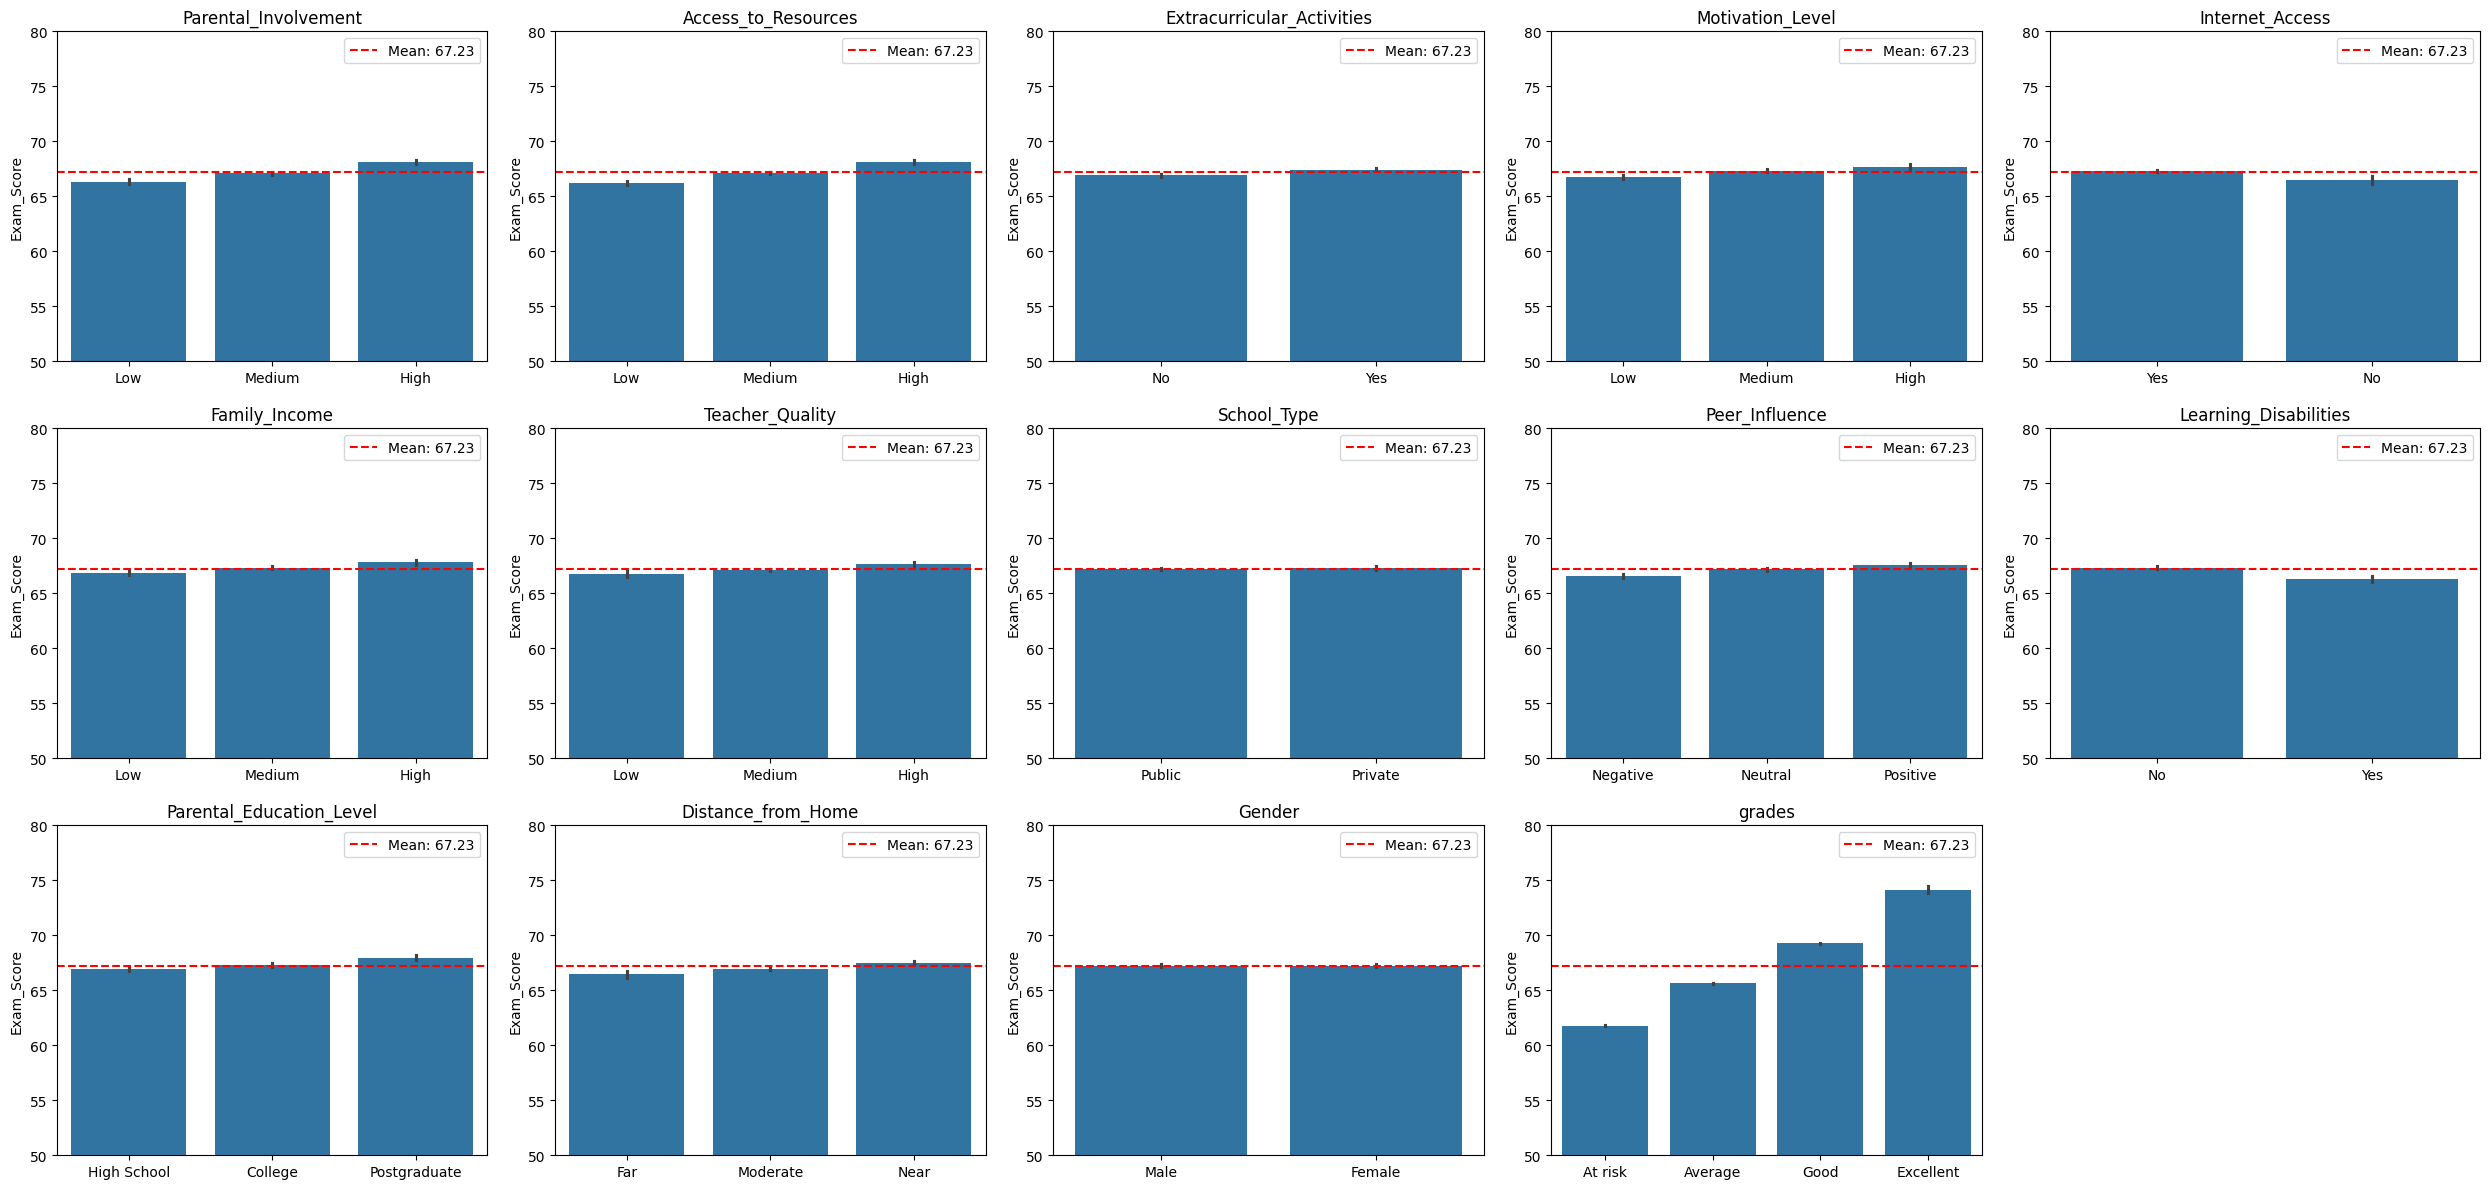

In [67]:
cat_cols = df.select_dtypes(exclude = "number").columns.to_list()

fig,axes = plt.subplots(nrows = 3, ncols = 5, figsize = (25,12))
axes = axes.flatten()

for i,col in enumerate(cat_cols):
  sns.barplot(df, x = col, y = "Exam_Score", ax = axes[i])
  axes[i].axhline(df["Exam_Score"].mean(), linestyle = "--", color = "red",
                  label = f"Mean: {df["Exam_Score"].mean():.2f}" )
  axes[i].legend()
  axes[i].set_title(col)
  axes[i].set_xlabel("")
  axes[i].set_ylim(50,80)


axes[14].set_visible(False)
plt.tight_layout(h_pad = 1.5,w_pad = 1.5)
plt.show()



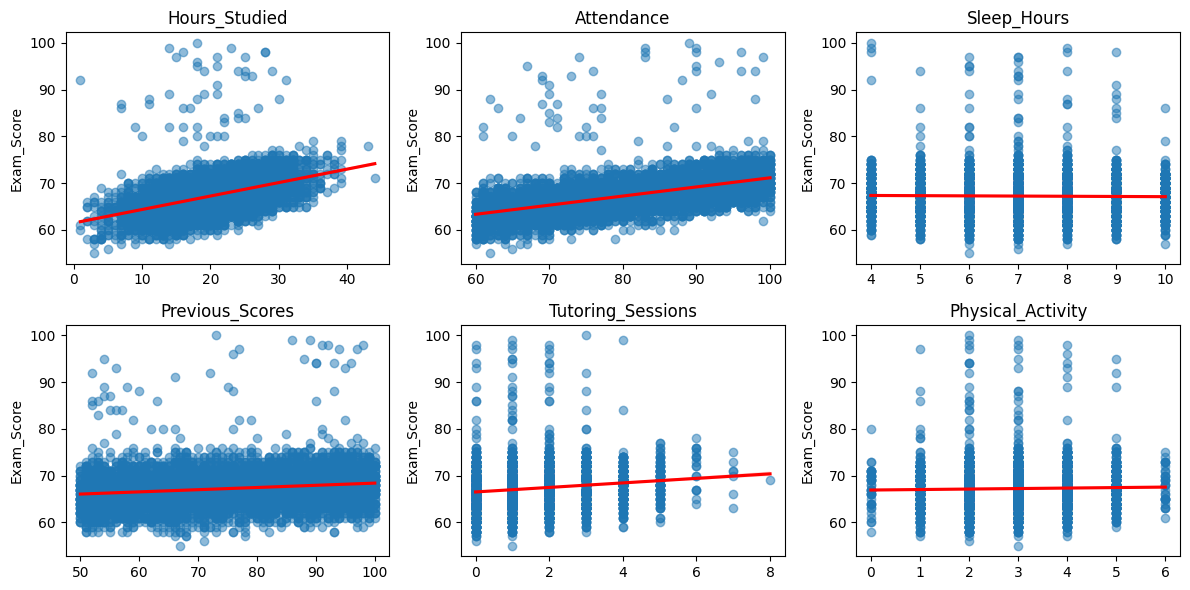

In [68]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12,6))
axes = axes.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.regplot(df, x = col, y = "Exam_Score", ax = axes[i], scatter_kws = {"alpha": 0.5}, line_kws = {"color":"red"})
  axes[i].set_title(col)
  axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

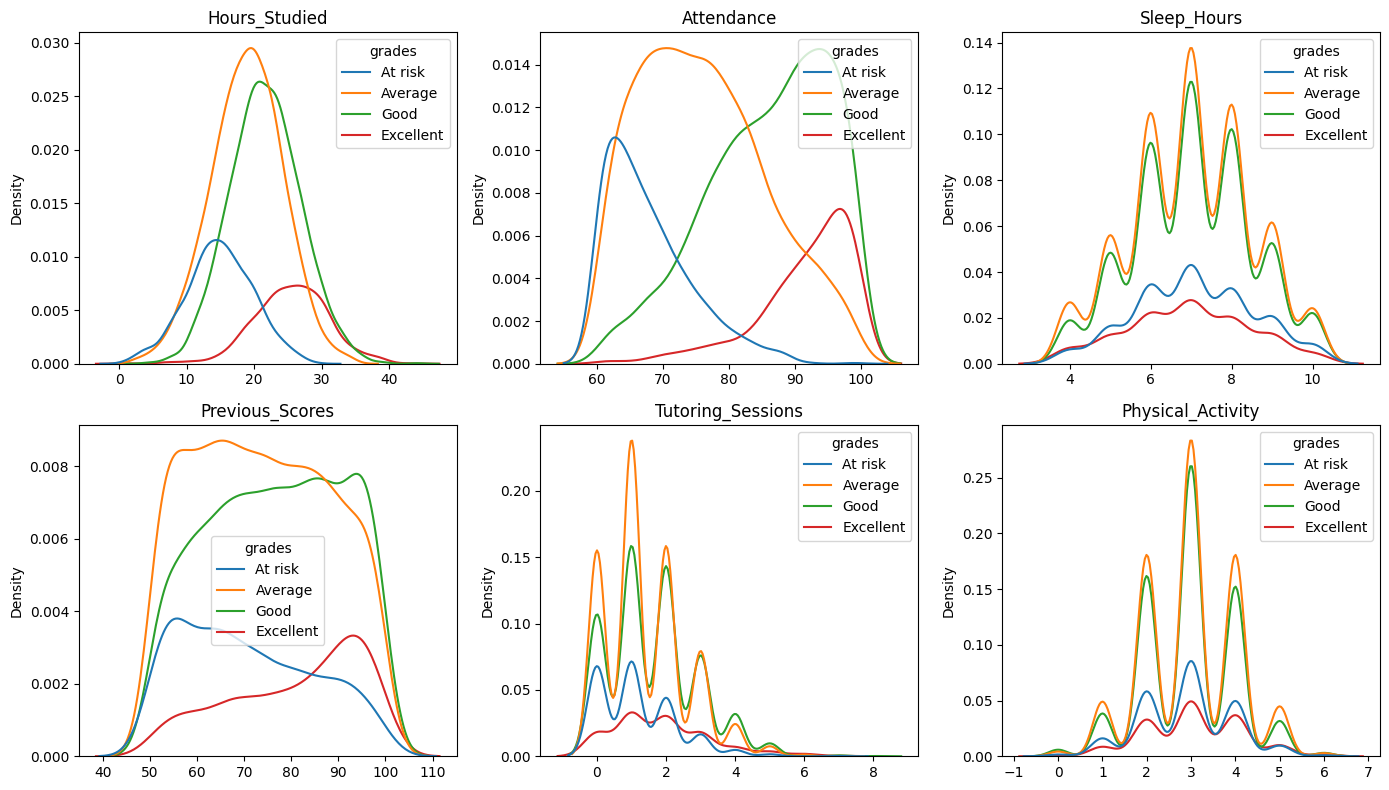

In [69]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (14,8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:-1]):
  sns.kdeplot(df, x = col, ax = axes[i], hue = "grades")
  axes[i].set_title(col)
  axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

In [70]:
# checking for Anova within Features variables across the grades.

labels = ["At risk", "Average", "Good", "Excellent"]

anova_results = []
for col in num_cols[:-1]:
  groups = [ df.loc[df["grades"] == g, col]  for g in labels]
  f,p = f_oneway(*groups)
  anova_results.append({
      "features": col,
      "f_stat": round(f,3),
      "p_value":round(p,3)
  })


anova_df = pd.DataFrame(anova_results)
anova_df

,features,f_stat,p_value
0,Hours_Studied,657.933,0.000
1,Attendance,1488.867,0.000
2,Sleep_Hours,1.739,0.157
3,Previous_Scores,81.732,0.000
4,Tutoring_Sessions,57.353,0.000
5,Physical_Activity,4.128,0.006


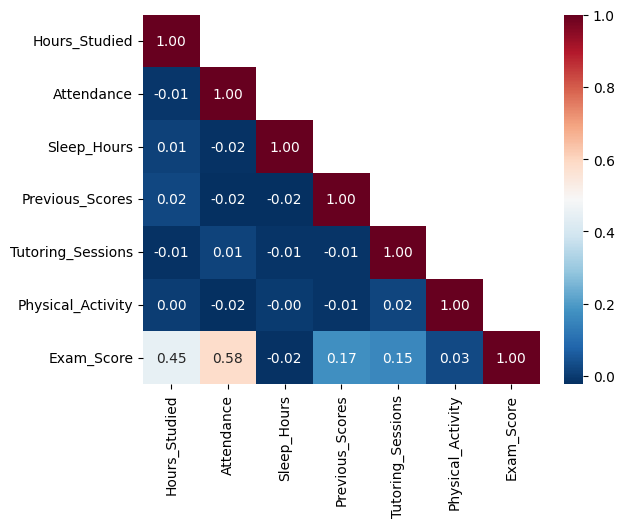

In [71]:
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype = bool), k = 1)

sns.heatmap(corr, annot = True, mask = mask, fmt = ".2f",
            cmap = "RdBu_r")

plt.show()

Learnings

Most categorical features show minimal variation in mean exam score
across their categories — bars remain close to the overall mean of 67.23.
This suggests that no single categorical feature alone is a strong
predictor of exam performance.
Categorical features likely matter collectively, not individually

KDE plots reveal WHERE in each feature's distribution the
grade bands separate — providing the most granular view of
feature-grade relationships.

> Attendance and study hours are the two strongest predictors of exam performance —
> both are behavioural, within student control, and directly actionable.


Sleep_Hours is the only feature that fails the significance test
(p = 0.157 > 0.05). We fail to reject the null hypothesis that
sleep hours are equal across grade bands. This feature will be
excluded from the final model

# **Supervised Machine learning**

Regression Model

- Predict the exact continuous Exam_Score (0-100) to measure the elasticity of specific features

In [72]:
dummy_vars = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities', 'Gender', "School_Type"]

df_enc = pd.get_dummies(df, columns = dummy_vars)

for col in ordinal_orders.keys():
  df_enc[col] = df_enc[col].cat.codes

In [73]:
x = df_enc.drop(columns = ["Exam_Score", "grades"], axis = 1)
y_reg = df_enc["Exam_Score"]

x_train, x_test, y_train, y_test = train_test_split(x,y_reg,test_size = 0.2, random_state = 11)

In [74]:
scale_cols = num_cols[:-1]

ct = ColumnTransformer(transformers = [("scaler", StandardScaler(), scale_cols)],
                       remainder = "passthrough")

pipeline = Pipeline([
    ("scaler", ct),
    ("model", LinearRegression())
])

param_grid = [
    {"model":[LinearRegression()] },
    { "model": [Lasso()], "model__alpha": [0.01,0.1,1,10,100] },
    { "model":[Ridge()], "model__alpha": [0.01,0.1,1,10] },
    { "model":[DecisionTreeRegressor(random_state =11)], "model__max_depth": [3,5,7,9] },
    {"model":[RandomForestRegressor(random_state =11)], "model__max_depth": [3,5,7,9], "model__n_estimators": [50,100,150,200]},
    {"model":[GradientBoostingRegressor(random_state = 11)], "model__max_depth": [3,5,7,9], "model__learning_rate":[0.05,0.1], "model__n_estimators": [50,100,150,200]}
    ]

kfold = KFold(n_splits = 5, shuffle = True, random_state = 11)

grid = GridSearchCV(pipeline, param_grid, cv = kfold,
                    scoring = ["neg_mean_squared_error", "r2"],
                    refit = "r2",
                    n_jobs = -1)

In [75]:
grid.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=KFold(n_splits=5, random_state=11, shuffle=True),
             estimator=Pipeline(steps=[('scaler',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scaler',
                                                                         StandardScaler(),
                                                                         ['Hours_Studied',
                                                                          'Attendance',
                                                                          'Sleep_Hours',
                                                                          'Previous_Scores',
                                                                          'Tutoring_Sessions',
                                                                          'Physical_Activity'])])),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid=[{'model'...
                          'model__max_depth': [3, 5, 7, 9]},
                         {'model': [RandomForestRegressor(random_state=11)],
                          'model__max_depth': [3, 5, 7, 9],
                          'model__n_estimators': [50, 100, 150, 200]},
                         {'model': [GradientBoostingRegressor(random_state=11)],
                          'model__learning_rate': [0.05, 0.1],
                          'model__max_depth': [3, 5, 7, 9],
                          'model__n_estimators': [50, 100, 150, 200]}],
             refit='r2', scoring=['neg_mean_squared_error', 'r2'])

In [76]:
print(f"Regression Best Model is :{grid.best_params_}")
print(f"Regression Score(train-set) : {grid.best_score_:.4f}")
print(f"Regression Score(Test set) :{grid.score(x_test, y_test):.4f}")

Regression Best Model is :{'model': Ridge(), 'model__alpha': 10}
Regression Score(train-set) : 0.7304
Regression Score(Test set) :0.7484


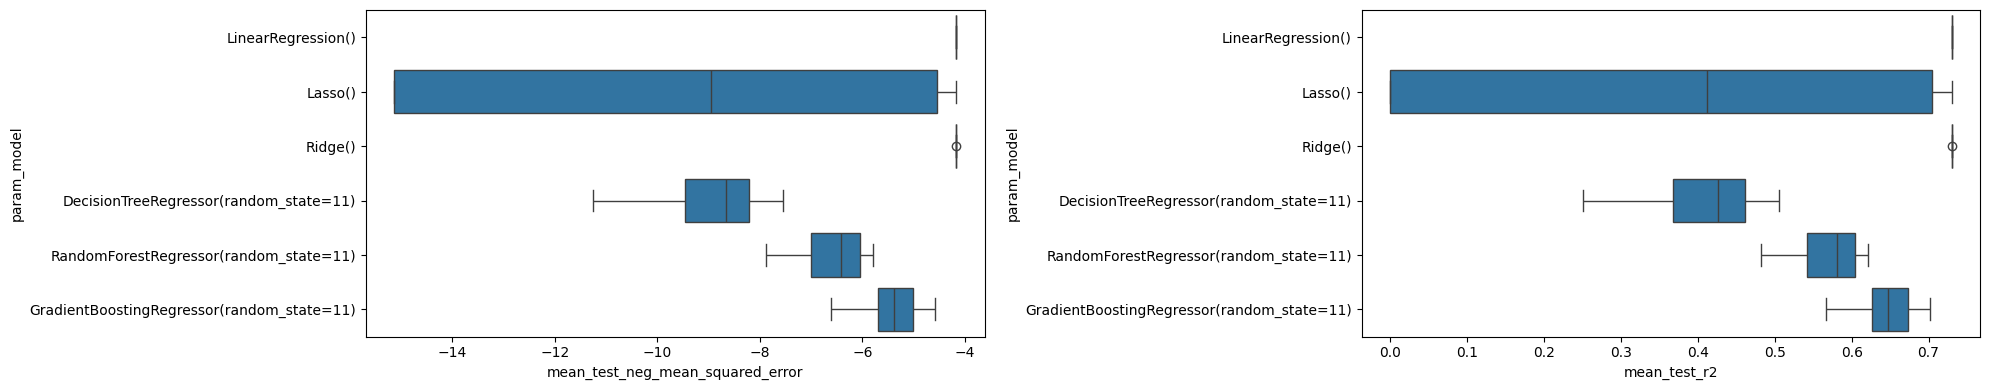

In [77]:
results_reg = pd.DataFrame(grid.cv_results_)[['param_model','mean_test_neg_mean_squared_error', 'std_test_neg_mean_squared_error',
       'rank_test_neg_mean_squared_error', 'mean_test_r2',
       'std_test_r2', 'rank_test_r2']]

fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (20,4))

for i, col in enumerate(['mean_test_neg_mean_squared_error', 'mean_test_r2']):

  sns.boxplot(results_reg, y = "param_model", x = col, ax = axes[i])


plt.tight_layout(w_pad = 1.5)
plt.show()

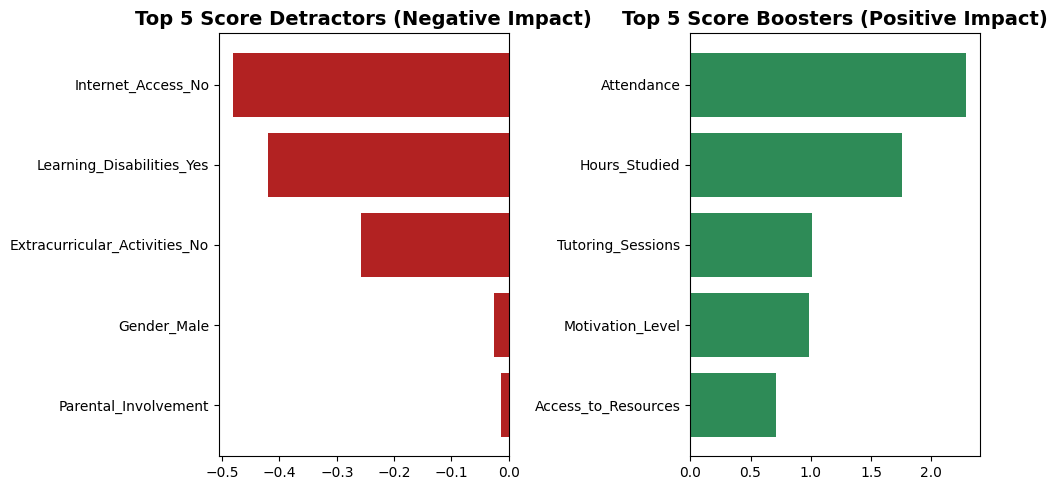

In [78]:
coef = grid.best_estimator_.named_steps["model"].coef_
features = grid.best_estimator_.named_steps["scaler"].feature_names_in_

importance_df = pd.DataFrame({"features": features, "coefficient": coef})

detractors = importance_df.sort_values(by="coefficient", ascending=True).head(5)

boosters = importance_df.sort_values(by="coefficient", ascending=False).head(5)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axes[0].barh(detractors["features"], detractors["coefficient"], color='firebrick')
axes[0].set_title("Top 5 Score Detractors (Negative Impact)", fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(boosters["features"], boosters["coefficient"], color='seagreen')
axes[1].set_title("Top 5 Score Boosters (Positive Impact)", fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Learnings:

- Ridge (α=10) won — train R² = 0.7304, test R² = 0.7484.
Test slightly > train indicates no overfitting; regularisation
shrunk coefficients just enough to generalise cleanly.

- Linear models (Ridge, Lasso, LinearRegression) outperformed
tree-based models (RF, GBM, DT) on this dataset.
This tells us the underlying score relationships are largely
**linear and additive** — no strong interactions or non-linearities
for trees to exploit.

- R² ≈ 0.75 means the model explains ~75% of variance in Exam_Score.

- Coefficient interpretation (Ridge, on standardised features):

**Boosters:** Attendance, Hours_Studied, Previous_Scores,
  Access_to_Resources, Parental_Involvement

**Detractors:** Learning_Disabilities_Yes, Distance_from_Home (Far),
  low Parental_Education

- Behavioural features (Attendance, Hours_Studied) carry the largest
positive weights — confirming the EDA finding and reinforcing that
the most predictive levers are also the most actionable

- mean_square_error - smaller is better

- r2 - higher is better

**Classification Model**

-Built an end-to-end predictive pipeline to forecast academic outcomes.

In [79]:
x = df_enc.drop(columns = ["Exam_Score", "grades"], axis = 1)
y_class = df_enc["grades"]

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x, y_class, test_size = 0.2, random_state =13)

In [ ]:
scale_cols = num_cols[:-1]

ct_class = ColumnTransformer(transformers = [("scaler", StandardScaler(), scale_cols)],
                       remainder = "passthrough")


models = {"logreg": LogisticRegression(solver = "liblinear"),
         "knn" : KNeighborsClassifier(),
         "tree": DecisionTreeClassifier(random_state = 13),
         "rf": RandomForestClassifier(random_state = 13) }

param_grid_class = {"logreg": {"model__C": [0.001,0.01,0.1,1,10], "model__penalty":["l1", "l2"]},
              "knn":{"model__n_neighbors":[3,5,7,9]},
              "tree":{"model__max_depth":[3,5,7,10],"model__min_samples_split":[2,3,5,7,10]},
              "rf":{"model__max_depth":[3,5,7,9], "model__n_estimators":[50,100,150,200]}}

cv_class = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 13)

model_results = []

for model_name, model in models.items():
  pipeline_class = Pipeline([
      ("scaler", ct_class),
      ("model", model) ])
  param_grid_model_name = param_grid_class[model_name]
  grid_class = GridSearchCV(pipeline_class, param_grid_model_name, cv = cv_class,
                            scoring = {"f1": "f1_weighted","accuracy": "accuracy",
                                       "recall": "recall_weighted","precision": "precision_weighted"},
                            refit = "f1",
                            )
  grid_class.fit(x_train_c, y_train_c)

  result_class = pd.DataFrame(grid_class.cv_results_)
  best_row = result_class.iloc[grid_class.best_index_]

  model_results.append({
      "model" : model_name,
      "best_params": str(grid_class.best_params_),
      "f1_score" : best_row["mean_test_f1"],
      "accuracy" : best_row["mean_test_accuracy"],
      "recall" : best_row["mean_test_recall"],
      "precision" : best_row["mean_test_precision"] })


class_df = pd.DataFrame(model_results)

In [81]:
print(class_df)

    model                                        best_params  f1_score  \
0  logreg           {'model__C': 10, 'model__penalty': 'l1'}  0.870491   
1     knn                          {'model__n_neighbors': 9}  0.672824   
2    tree  {'model__max_depth': 10, 'model__min_samples_s...  0.674846   
3      rf  {'model__max_depth': 9, 'model__n_estimators':...  0.698809   

   accuracy    recall  precision  
0  0.875097  0.875097   0.883926  
1  0.684141  0.684141   0.707281  
2  0.675814  0.675814   0.676005  
3  0.721992  0.721992   0.763969  


**Recommendations:**

Implement early warning system — flag students below 75% attendance for immediate pastoral intervention.

Study skills workshops for first-year students.
Structured study time programmes for at-risk cohort.

Each additional tutoring session correlates with score improvement.
Prioritise tutoring resources for at-risk students identified by the classification model

Counter to popular belief, sleep hours do not significantly
differ across grade bands in this dataset.

# **Unsupervised Learning:**

-Before predicting scores, we must understand the students.

-Clustering tells us *why groups of students differ* —
without using exam scores as a label

In [82]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

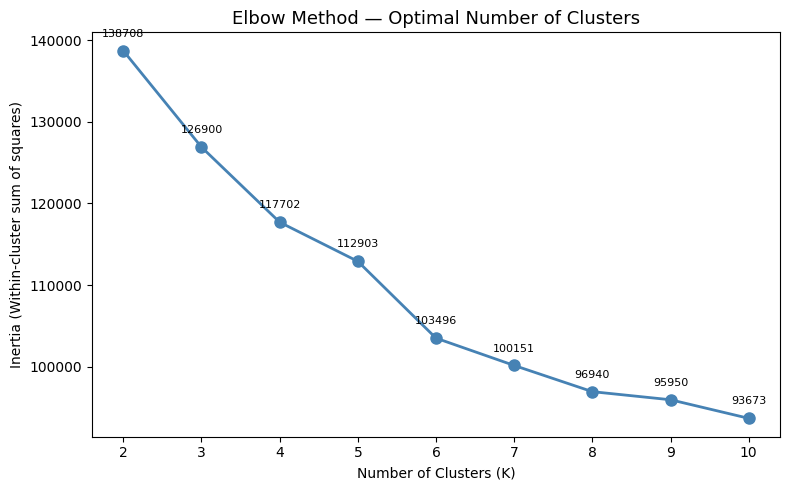

In [83]:
cluster_features = df_enc.drop(columns=[
    "Exam_Score",       # target — leakage
    "grades",           # derived from target — leakage
    "Sleep_Hours"       # statistically insignificant (p=0.157)
]).columns.tolist()

X_cluster = df_enc[cluster_features].copy()

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_range, inertias, marker="o",
        color="steelblue", linewidth=2, markersize=8)

# Annotate each point with inertia value
for k, inertia in zip(K_range, inertias):
    ax.annotate(f"{inertia:.0f}",
                xy=(k, inertia),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center", fontsize=8)

ax.set_title("Elbow Method — Optimal Number of Clusters",
             fontsize=13)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-cluster sum of squares)")
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

In [84]:
optimal_k = 4

km_final = KMeans(n_clusters=optimal_k,
                   random_state=42,
                   n_init=10)

df_enc["Cluster"] = km_final.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(df_enc["Cluster"].value_counts().sort_index())

Cluster distribution:
Cluster
0    2287
1    3175
2     498
3     646
Name: count, dtype: int64


In [85]:
profile_cols = ["Hours_Studied", "Attendance", "Previous_Scores",
                "Tutoring_Sessions", "Physical_Activity",
                "Exam_Score"]

cluster_profile = (df_enc.groupby("Cluster")[profile_cols]
                          .mean()
                          .round(2))

print("Cluster Profiles:")
print(cluster_profile)

Cluster Profiles:
         Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions  \
Cluster                                                                  
0                19.97       79.85            75.34               1.49   
1                20.04       80.11            74.85               1.48   
2                19.86       80.68            74.82               1.53   
3                19.78       79.23            75.38               1.54   

         Physical_Activity  Exam_Score  
Cluster                                 
0                     2.94       67.60  
1                     2.98       67.26  
2                     3.01       66.47  
3                     3.00       66.37  


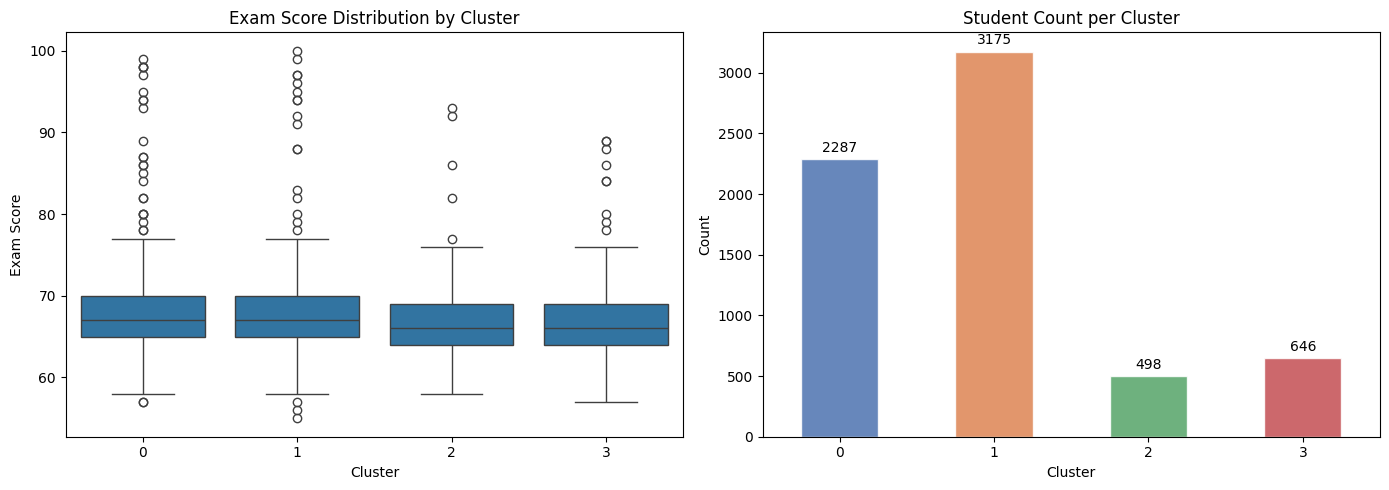

In [86]:
palette = {0: "#4C72B0", 1: "#DD8452", 2: "#55A467", 3: "#C44E52"}

# ── Step 7: Exam score distribution per cluster ─────────────────
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df_enc, x="Cluster", y="Exam_Score",
            ax=axes[0])
axes[0].set_title("Exam Score Distribution by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Exam Score")

# Count per cluster
df_enc["Cluster"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1],
    color=list(palette.values()),
    alpha=0.85, edgecolor="white")
axes[1].set_title("Student Count per Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

**Project Summary:**


1. Attendance and study hours are the two most controllable
   predictors of academic performance
2. Sleep hours show no statistically significant impact (p=0.157)
3. Socioeconomic factors (Family_Income, Access_to_Resources)
   influence outcomes — equity interventions are justified
4. Four distinct student archetypes exist — each requiring
   a different institutional response
5. The clustering model enables proactive intervention
   before exam results exist

**Limitations:**

- Dataset is synthetic — real deployment would require validation
- Clustering labels are interpretive —